# **Emotion Recognition with Tensorflow 2.0 and Python**

In this section, will be discussed how to create models capable of identifying emotions on images/videos, as well as its implementation, using Tensorflow and Python

## What is the detection of emotions and facial expressions?

It is making a model capable of processing data from people's face image and provide probabilities about which feeling is being expressed by it.

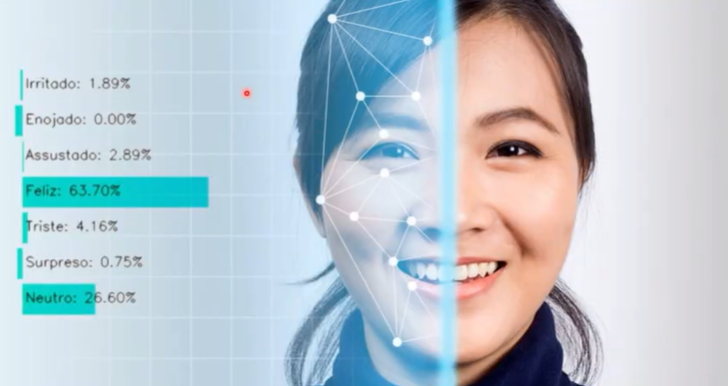

### Facial expressions

Facial expressions provide information about the emotional response of a person given an action, being very important for human interaction and as a way of non-verbal communication. They may complement verbal communication or even transmit a complete message by itself, as well as complementing for the effect of a message more than intonation or the message itself. The best model to process this kind of data are CNNs.

### Applications

- Smart Cars: alerting distracted conductors; finding the best moment to hand over the steering to the driver.
- Games: developing NPCs that can react to the player's expression;
- Health: monitoring pacients;
- Education: assessment of student interest;
- Marketing: understanding better how clients feel as they consume some product; generating smart environments that suit music and lighting to beneift well-being in order to promote a sale;
- Cinema: audience movie scene reaction;

## Time to Code!

In [1]:
# First step: importing the libraries:
import cv2 # emotion detection
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
tf.__version__

'2.12.0'

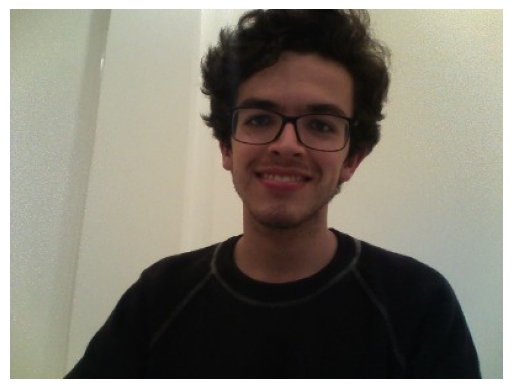

In [2]:
# Testing if the directories are being read correctly
imagem = cv2.imread('Material/testes/teste_gabriel.png')
plt.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Now, pre-trained models will be loaded and tested accordingly to the sample images:

In [3]:
cascade_faces='Material/haarcascade_frontalface_default.xml'
model_path='Material/modelo_01_expressoes.h5'
face_detection=cv2.CascadeClassifier(cascade_faces) # Object to make face detection
classify_emotions=load_model(model_path, compile=False) # Since its pretrained, no need for compiling
expressions=['Anger','Disgust','Fear','Happy','Sad','Surprised','Neutral']

#### Face detection:

In [4]:
original = imagem.copy()
faces = face_detection.detectMultiScale(original, scaleFactor=1.1,
                                        minNeighbors=3, minSize=(20,20))
# minSize refers to the minimal size that a face can take in an image (pixels). The higher, the more accurate.

In [5]:
faces

array([[162,  40, 128, 128]])

Above, 162 and 40 refers, respectively, to the X and Y coordinates that the face was first found in the image. 128 and 128 refers to the space in the image reserved for the face, like a bounding box.

In [6]:
len(faces) # Number of faces detected

1

#### ROI Extraction (Region Of Interest)

Firstly, its needed to convert the image to the grayscale, since its better for computational performance and does not change the results at all.

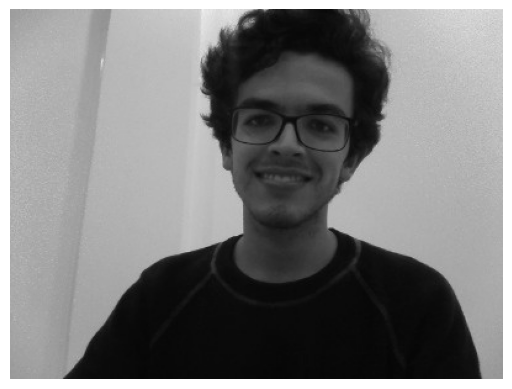

In [7]:
gray = cv2.cvtColor(original,cv2.COLOR_BGR2GRAY) # Converting the image into grayscale

plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

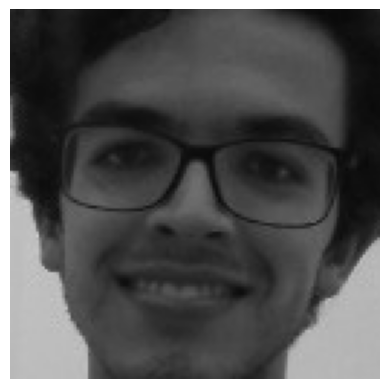

In [8]:
# Extracting the ROI
roi = gray[40:40+128, 162:162 + 128] # Dissecting the image according to the variables returned by the 'faces' object.

plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [9]:
roi.shape

(128, 128)

In [10]:
roi 
# Here, this represents the values of pixels of the ROI image, in which each number represent the color represented by the pixel
# where 0 is black and 255 is white.

array([[ 39,  37,  28, ...,  25,  29,  34],
       [ 34,  32,  25, ...,  24,  24,  29],
       [ 31,  33,  30, ...,  23,  22,  26],
       ...,
       [184, 185, 186, ..., 180, 181, 181],
       [184, 185, 186, ..., 179, 181, 180],
       [184, 185, 187, ..., 180, 181, 180]], dtype=uint8)

Since the image is still quite large for processing, it can be reshaped in order to get smaller so it does not take much time to process it all:

*PS: of course, the higher the resolution, the more precise it will be, but for this case, does not really matter that much*

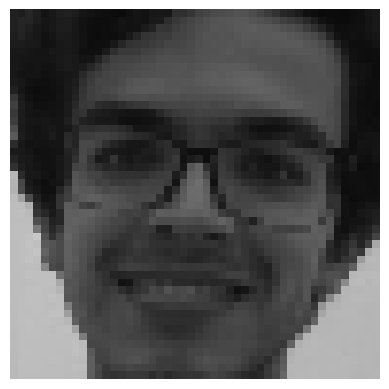

In [11]:
roi = cv2.resize(roi, (48,48))

plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [12]:
roi.dtype

dtype('uint8')

As it can be seen above, at the moment, the image is full of integers. So that means they need to be normalized for faster processing in the neural network, making all its values between 0 and 1:

In [13]:
roi = roi.astype('float')
roi.dtype

dtype('float64')

In [14]:
roi

array([[ 33.,  29.,  38., ...,  16.,  22.,  25.],
       [ 32.,  37.,  37., ...,  16.,  20.,  25.],
       [ 32.,  36.,  31., ...,  17.,  21.,  25.],
       ...,
       [186., 189., 189., ..., 181., 181., 180.],
       [185., 188., 189., ..., 180., 181., 180.],
       [185., 188., 188., ..., 179., 180., 181.]])

In [15]:
roi = roi / 255

In [16]:
roi

array([[0.12941176, 0.11372549, 0.14901961, ..., 0.0627451 , 0.08627451,
        0.09803922],
       [0.1254902 , 0.14509804, 0.14509804, ..., 0.0627451 , 0.07843137,
        0.09803922],
       [0.1254902 , 0.14117647, 0.12156863, ..., 0.06666667, 0.08235294,
        0.09803922],
       ...,
       [0.72941176, 0.74117647, 0.74117647, ..., 0.70980392, 0.70980392,
        0.70588235],
       [0.7254902 , 0.7372549 , 0.74117647, ..., 0.70588235, 0.70980392,
        0.70588235],
       [0.7254902 , 0.7372549 , 0.7372549 , ..., 0.70196078, 0.70588235,
        0.70980392]])

Now that it is successfully converted, time to pass it as an array, so it can fit the first layer in the neural network:

In [17]:
roi = img_to_array(roi)

In [18]:
roi

array([[[0.12941177],
        [0.11372549],
        [0.14901961],
        ...,
        [0.0627451 ],
        [0.08627451],
        [0.09803922]],

       [[0.1254902 ],
        [0.14509805],
        [0.14509805],
        ...,
        [0.0627451 ],
        [0.07843138],
        [0.09803922]],

       [[0.1254902 ],
        [0.14117648],
        [0.12156863],
        ...,
        [0.06666667],
        [0.08235294],
        [0.09803922]],

       ...,

       [[0.7294118 ],
        [0.7411765 ],
        [0.7411765 ],
        ...,
        [0.70980394],
        [0.70980394],
        [0.7058824 ]],

       [[0.7254902 ],
        [0.7372549 ],
        [0.7411765 ],
        ...,
        [0.7058824 ],
        [0.70980394],
        [0.7058824 ]],

       [[0.7254902 ],
        [0.7372549 ],
        [0.7372549 ],
        ...,
        [0.7019608 ],
        [0.7058824 ],
        [0.70980394]]], dtype=float32)

In [19]:
roi.shape # 48, 48 means pixel resolution, and 1 represent the amount of color channels (1 is just black/white)

(48, 48, 1)

In [20]:
roi = np.expand_dims(roi, axis=0)

In [21]:
roi.shape

(1, 48, 48, 1)

This expansion was made just for the image to fit tensorflow' sintax, where the first number (1) represent the amount of images, 48x48 the resolution, and the last digit (1), the amount of color channels. Now, it's ready to be fit into a neural network:

In [22]:
preds = classify_emotions.predict(roi)[0]

1/1 [==============================] - 0s 278ms/step


In [23]:
preds

array([1.6802145e-05, 5.7679888e-09, 1.1206589e-05, 9.9066460e-01,
       1.8033788e-05, 1.8518314e-05, 9.2708301e-03], dtype=float32)

In [24]:
# Visualizing the highest probability value
emotion_probability = np.max(preds)
emotion_probability

0.9906646

This value was found in the third position, but it still doesnt mean anything. So its time to create the labels and assigned them their respective values:

In [25]:
label = expressions[preds.argmax()]
label

'Happy'

With this, it's possible to conclude that the image used in test, express the feeling of happiness.

### For the following exercise, the FER2013 dataset will be used:

FER2013 is an open-source dataset consisting of 35,887 48x48 grayscale face images, with a total of 7 labeled emotions.

Below, is the graph that shows how many images of each emotion is available in the dataset (0=Angry,1=Disgust,2=Fear,3=Happy,4=Sad,5=Surprise,6=Neutral):

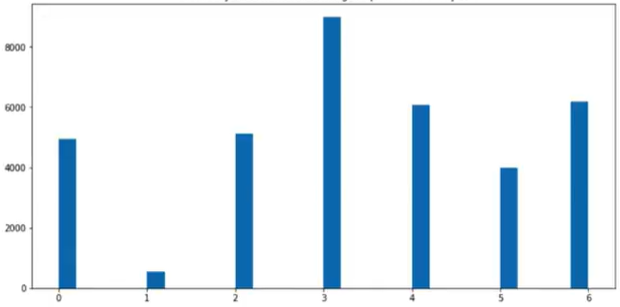

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [7]:
# Acessing the database
data = pd.read_csv('fer2013/fer2013.csv')
# All of the gray pixel values present in the images are present in this csv file.
data.tail()

,emotion,pixels,Usage
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest
35886,2,19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...,PrivateTest


Text(0.5, 1.0, 'Images x Emotions')

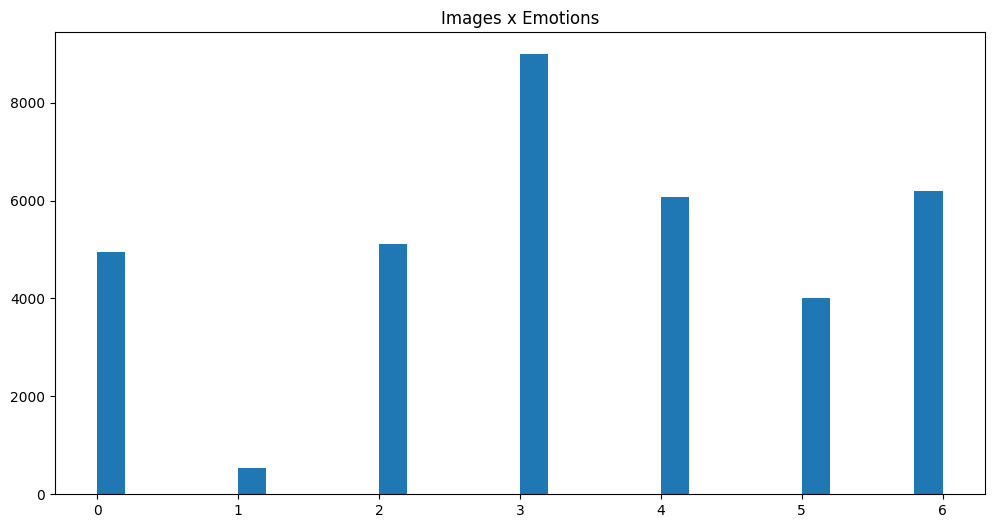

In [3]:
plt.figure(figsize=(12,6))
plt.hist(data['emotion'], bins=30)
plt.title('Images x Emotions')

# Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

In [8]:
# Data preprocessing
pixels = data['pixels'].tolist()
# Now, each row is an image.

width, height = 48, 48
faces = []
for pixel_sequence in pixels:
    face = [int(pixel) for pixel in pixel_sequence.split(' ')]
    face = np.asarray(face).reshape(width, height)
    faces.append(face)

In [5]:
# Now, the images pixels are now organized correctly:
faces

[array([[ 70,  80,  82, ...,  52,  43,  41],
        [ 65,  61,  58, ...,  56,  52,  44],
        [ 50,  43,  54, ...,  49,  56,  47],
        ...,
        [ 91,  65,  42, ...,  72,  56,  43],
        [ 77,  82,  79, ..., 105,  70,  46],
        [ 77,  72,  84, ..., 106, 109,  82]]),
 array([[151, 150, 147, ..., 129, 140, 120],
        [151, 149, 149, ..., 122, 141, 137],
        [151, 151, 156, ..., 109, 123, 146],
        ...,
        [188, 188, 121, ..., 185, 185, 186],
        [188, 187, 196, ..., 186, 182, 187],
        [186, 184, 185, ..., 193, 183, 184]]),
 array([[231, 212, 156, ...,  44,  27,  16],
        [229, 175, 148, ...,  27,  35,  27],
        [214, 156, 157, ...,  28,  22,  28],
        ...,
        [241, 245, 250, ...,  57, 101, 146],
        [246, 250, 252, ...,  78, 105, 162],
        [250, 251, 250, ...,  88, 110, 152]]),
 array([[ 24,  32,  36, ..., 173, 172, 173],
        [ 25,  34,  29, ..., 173, 172, 173],
        [ 26,  29,  25, ..., 172, 172, 174],
        ..

In [6]:
print('Total amount of images in the dataset: ',str(len(faces))) 

Total amount of images in the dataset:  35887


In [9]:
# Converting to nparray so it can be passed to tensorflow

faces = np.asarray(faces)

In [8]:
faces.shape

(35887, 48, 48)

In [10]:
faces = np.expand_dims(faces, -1)
faces.shape
# Adding new dimension to indicate amount of colors 

(35887, 48, 48, 1)

Now it's needed to normalize each pixel value to the interval from 0 to 1:

In [11]:
def normalize(x):
    x = x.astype('float32')
    x = x / 255.0
    return x

faces = normalize(faces)

In [11]:
faces

array([[[[0.27450982],
         [0.3137255 ],
         [0.32156864],
         ...,
         [0.20392157],
         [0.16862746],
         [0.16078432]],

        [[0.25490198],
         [0.23921569],
         [0.22745098],
         ...,
         [0.21960784],
         [0.20392157],
         [0.17254902]],

        [[0.19607843],
         [0.16862746],
         [0.21176471],
         ...,
         [0.19215687],
         [0.21960784],
         [0.18431373]],

        ...,

        [[0.35686275],
         [0.25490198],
         [0.16470589],
         ...,
         [0.28235295],
         [0.21960784],
         [0.16862746]],

        [[0.3019608 ],
         [0.32156864],
         [0.30980393],
         ...,
         [0.4117647 ],
         [0.27450982],
         [0.18039216]],

        [[0.3019608 ],
         [0.28235295],
         [0.32941177],
         ...,
         [0.41568628],
         [0.42745098],
         [0.32156864]]],


       [[[0.5921569 ],
         [0.5882353 ],
         [0.57

Now, the pixel values are all between 0 and 1 (normalized)

In [12]:
emotions = pd.get_dummies(data['emotion']).values

In [13]:
emotions

array([[ True, False, False, ..., False, False, False],
       [ True, False, False, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [ True, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False,  True, ..., False, False, False]])

In [14]:
emotions[0]

array([ True, False, False, False, False, False, False])

Now, it appears True for the respective emotion that's being represented by the image.

Below, lets model the model:

In [15]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.models import model_from_json

In [13]:
X_train, X_test, y_train, y_test = train_test_split(faces, emotions, test_size=0.15, random_state=42)
_, X_val, _, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=41)

In [17]:
print('Amount of images on the training set:',len(X_train))
print('Amount of images on the testing set:',len(X_test))
print('Amount of images on the validation set:',len(X_val))

Amount of images on the training set: 30503
Amount of images on the testing set: 5384
Amount of images on the validation set: 4576


Building the architecture for our CNN model

In [18]:
num_features = 64
num_labels = 7
batch_size = 64
epochs = 5
w, h = 48,48

model = Sequential()

model.add(Conv2D(num_features, kernel_size=(3,3), activation='relu', input_shape=(w,h,1), data_format='channels_last', kernel_regularizer=l2(0.01)))
model.add(Conv2D(num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.5))

model.add(Conv2D(2*num_features, kernel_size=(3,3), activation='relu', input_shape=(w,h,1), padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(2*num_features, kernel_size=(3,3), activation='relu', input_shape=(w,h,1), padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.5))

model.add(Conv2D(2*2*num_features, kernel_size=(3,3), activation='relu', input_shape=(w,h,1), padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*num_features, kernel_size=(3,3), activation='relu', input_shape=(w,h,1), padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.5))

model.add(Conv2D(2*2*2*num_features, kernel_size=(3,3), activation='relu', input_shape=(w,h,1), padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*2*num_features, kernel_size=(3,3), activation='relu', input_shape=(w,h,1), padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.5))

model.add(Flatten()) # Flattening the output so it can fit into the first layer of a dense neural network

model.add(Dense(2*2*2*num_features, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(2*2*num_features, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(2*num_features, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_labels, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 46, 46, 64)        640       
                                                                 
 conv2d_1 (Conv2D)           (None, 46, 46, 64)        36928     
                                                                 
 batch_normalization (BatchN  (None, 46, 46, 64)       256       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 23, 23, 64)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 23, 23, 64)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 23, 23, 128)       7

Now, let's compile the model:

In [34]:
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999,epsilon=1e-7), metrics=['accuracy'])

model_file = 'modelo_01_expressoes.h5'
model_file_json = 'modelo_01_expressoes.json'

lr_reducer = ReduceLROnPlateau(monitor='val_loss',factor=0.9, patience=3, verbose=1)
# In neural networks, its quite common to hit a plateou when training the model, which makes the accuracy and loss not to go up/down, respectively.
# When this happens, functions like ReduceLROnPlateau helps the model to go back on track and resume its progress. 
# It works by multilying the learning rate by the factor (0.9) after tha patience runs out (3 epochs without progress)
early_stopper = EarlyStopping(monitor='val_loss', min_delta=0,patience=8,verbose=1,mode='auto')
# An early stopper helps with saving performance by automatically stopping the training if after 8 (patience) epochs it does not show any progress.
checkpointer = ModelCheckpoint(model_file, monitor='val_loss', verbose=1,save_best_only=True)
# The ModelCheckpoint makes possible to save the state of the model at each epoch, helping with choosing which one suits its purpose the best,
# specially when the last epoch isn't the best. When save_best_only is marked as True, it saves only the best epoch based on its monitor class, 
# that in this case, is 'val_loss'

In [20]:
history = model.fit(np.array(X_train), np.array(y_train),
                   batch_size = batch_size,
                   epochs = epochs,
                   verbose = 1,
                   validation_data = (np.array(X_val),np.array(y_val)),
                   shuffle=True,
                   callbacks=[lr_reducer, early_stopper, checkpointer])

Epoch 1/5
477/477 [==============================] - ETA: 0s - loss: 1.9811 - accuracy: 0.2155
Epoch 1: val_loss improved from inf to 1.81891, saving model to modelo_01_expressoes.json


INFO:tensorflow:Assets written to: modelo_01_expressoes.json\assets


INFO:tensorflow:Assets written to: modelo_01_expressoes.json\assets


477/477 [==============================] - 621s 1s/step - loss: 1.9811 - accuracy: 0.2155 - val_loss: 1.8189 - val_accuracy: 0.2507 - lr: 0.0010
Epoch 2/5
477/477 [==============================] - ETA: 0s - loss: 1.8283 - accuracy: 0.2462
Epoch 2: val_loss improved from 1.81891 to 1.80479, saving model to modelo_01_expressoes.json


INFO:tensorflow:Assets written to: modelo_01_expressoes.json\assets


INFO:tensorflow:Assets written to: modelo_01_expressoes.json\assets


477/477 [==============================] - 625s 1s/step - loss: 1.8283 - accuracy: 0.2462 - val_loss: 1.8048 - val_accuracy: 0.2507 - lr: 0.0010
Epoch 3/5
477/477 [==============================] - ETA: 0s - loss: 1.8018 - accuracy: 0.2609
Epoch 3: val_loss did not improve from 1.80479
477/477 [==============================] - 629s 1s/step - loss: 1.8018 - accuracy: 0.2609 - val_loss: 1.8400 - val_accuracy: 0.2515 - lr: 0.0010
Epoch 4/5
477/477 [==============================] - ETA: 0s - loss: 1.7110 - accuracy: 0.3100
Epoch 4: val_loss did not improve from 1.80479
477/477 [==============================] - 618s 1s/step - loss: 1.7110 - accuracy: 0.3100 - val_loss: 1.8346 - val_accuracy: 0.2458 - lr: 0.0010
Epoch 5/5
477/477 [==============================] - ETA: 0s - loss: 1.5873 - accuracy: 0.3728
Epoch 5: val_loss improved from 1.80479 to 1.66047, saving model to modelo_01_expressoes.json


INFO:tensorflow:Assets written to: modelo_01_expressoes.json\assets


INFO:tensorflow:Assets written to: modelo_01_expressoes.json\assets


477/477 [==============================] - 627s 1s/step - loss: 1.5873 - accuracy: 0.3728 - val_loss: 1.6605 - val_accuracy: 0.3407 - lr: 0.0010


### Now that the training is over, let's generate some charts based on the training data:

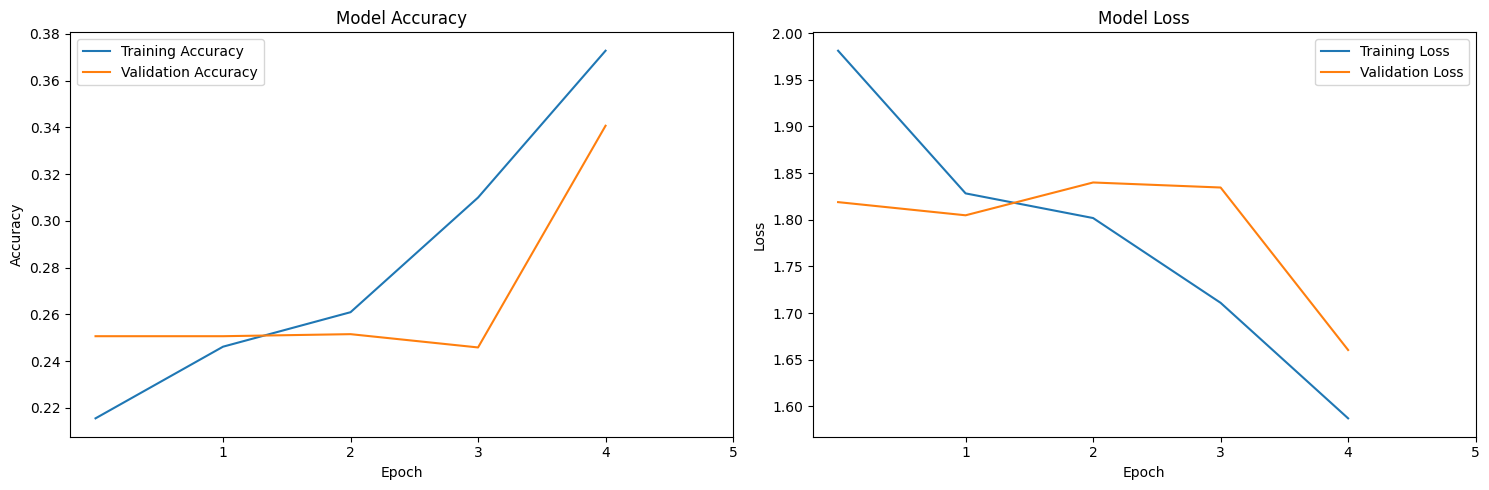

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_model_history(model_hist):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    # Subplot 0: Training and Validation Accuracy
    axs[0].plot(model_hist.history['accuracy'])
    axs[0].plot(model_hist.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    
    # Generate evenly spaced tick positions
    num_epochs = len(model_hist.history['accuracy'])
    xticks = np.arange(1, num_epochs + 1, max(1, num_epochs // 10))
    
    axs[0].set_xticks(xticks)
    axs[0].legend(['Training Accuracy', 'Validation Accuracy'], loc='best')

    # Subplot 1: Training and Validation Loss
    axs[1].plot(model_hist.history['loss'])
    axs[1].plot(model_hist.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_xticks(xticks)
    axs[1].legend(['Training Loss', 'Validation Loss'], loc='best')

    plt.tight_layout()
    plt.show()

plot_model_history(history)

### Verifying the model accuracy based on the test dataset

In [27]:
scores = model.evaluate(np.array(X_test), np.array(y_test), batch_size=batch_size)

85/85 [==============================] - 21s 241ms/step - loss: 1.6763 - accuracy: 0.3273


In [29]:
print('Accuracy Based on the Test Split Dataset: '+str(scores[1]))
print('Error Based on the Test Split Dataset: '+str(scores[0]))

Accuracy Based on the Test Split Dataset: 0.32726597785949707
Error Based on the Test Split Dataset: 1.6762573719024658


_The reason for the accuracy to be that low is that I had to drastically reduce the amount of epochs so it could be faster, since I am using a laptop with no GPU_

### Generating a Confusion Matrix based on the results 

In [30]:
np.save('mod_xtest', X_test)
np.save('mod_ytest', y_test)

In [31]:
true_y = []
pred_y = []
x = np.load('mod_xtest.npy')
y = np.load('mod_ytest.npy')

x[0]

array([[[0.5568628 ],
        [0.5803922 ],
        [0.59607846],
        ...,
        [0.3529412 ],
        [0.3529412 ],
        [0.3647059 ]],

       [[0.5568628 ],
        [0.5764706 ],
        [0.5921569 ],
        ...,
        [0.33333334],
        [0.36078432],
        [0.40392157]],

       [[0.5529412 ],
        [0.5686275 ],
        [0.5921569 ],
        ...,
        [0.3372549 ],
        [0.32156864],
        [0.37254903]],

       ...,

       [[0.0627451 ],
        [0.08235294],
        [0.07058824],
        ...,
        [0.08235294],
        [0.09019608],
        [0.11372549]],

       [[0.05490196],
        [0.0627451 ],
        [0.05490196],
        ...,
        [0.07450981],
        [0.07843138],
        [0.09803922]],

       [[0.04705882],
        [0.04705882],
        [0.04705882],
        ...,
        [0.06666667],
        [0.07450981],
        [0.09411765]]], dtype=float32)

In [32]:
y[0]

array([False, False, False,  True, False, False, False])

In [40]:
model_file_json = 'Material/modelo_05_expressoes.json'
model_file = 'Material/modelo_05_expressoes.h5'
json_file = open(model_file_json, 'r')
# Pretty straight-foward, just loading a model and its weights from json and h5 files.
loaded_model_json = json_file.read()
json_file.close()

In [41]:
loaded_model = model_from_json(loaded_model_json)
loaded_model.load_weights(model_file)

In [42]:
y_pred = loaded_model.predict(x)

169/169 [==============================] - 23s 137ms/step


In [44]:
y_pred[0]

array([0.13303782, 0.02056069, 0.15164751, 0.24085976, 0.16180702,
       0.11981051, 0.17227674], dtype=float32)

In [47]:
yp = y_pred.tolist()
yt = y.tolist()
count = 0

for i in range(len(y)):
    yy = max(yp[i])
    yyt = max(yt[i])
    pred_y.append(yp[i].index(yy))
    true_y.append(yt[i].index(yyt))
    if (yp[i].index(yy) == yt[i].index(yyt)):
        count+=1

acc = (count / len(y)) * 100

In [48]:
print('Accuracy in the test data: '+str(acc))

Accuracy in the test data: 24.275631500742943


In [49]:
np.save('truey_mod01',true_y)
np.save('pred_mod01',pred_y)

Now that both the prediction and real values are stored into files, the confusion matrix can now finally be created: 

In [50]:
from sklearn.metrics import confusion_matrix

In [61]:
y_true = np.load('truey_mod01.npy')
y_pred = np.load('pred_mod01.npy')

In [67]:
cm = confusion_matrix(y_true, y_pred)
expressions = ['Angry', 'Disgust', 'Fear', 'Happy','Surprised','Neutral']
title = 'Confusion Matrix'
print(cm)

[[   0    0    0  756    0    0    0]
 [   0    0    0   81    0    0    0]
 [   0    0    0  801    0    0    0]
 [   0    0    0 1307    0    0    0]
 [   0    0    0  900    0    0    0]
 [   0    0    0  601    0    0    0]
 [   0    0    0  939    0    0    0]]


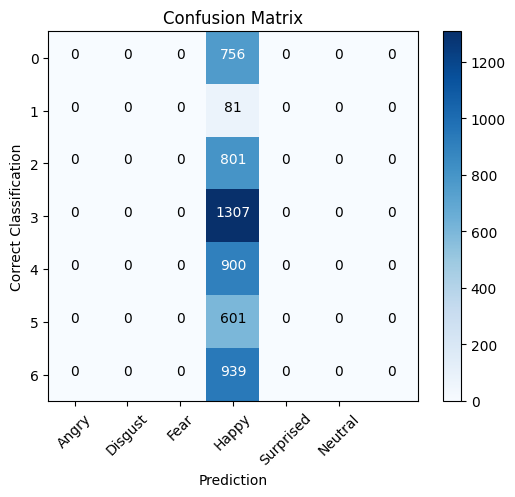

In [71]:
import itertools
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(title)
plt.colorbar()
tick_marks = np.arange(len(expressions))
plt.xticks(tick_marks, expressions, rotation=45)
fmt = 'd'
thresh = cm.max() /2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i,j],fmt), horizontalalignment='center',color='white' if cm[i,j] > thresh else 'black')

plt.ylabel('Correct Classification')
plt.xlabel('Prediction')
plt.savefig('confusion_matrix_mod01.png')

## Testing the Model

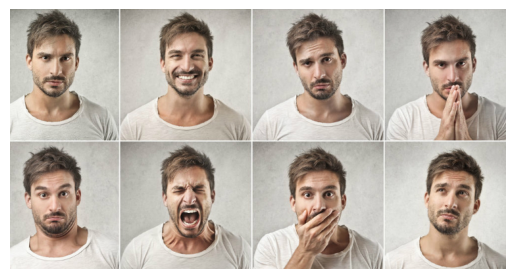

In [72]:
# Here, even though the model isnt presenting a good accuracy due to low epochs during training (unfortunately, im using an extreme old laptop),
# the model will be tested into some other random images. Since it will probably predict most of things wrongly,its safe to say that this is for
# educational/learning purposes only.

image = cv2.imread('Material/testes/teste02.jpg')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

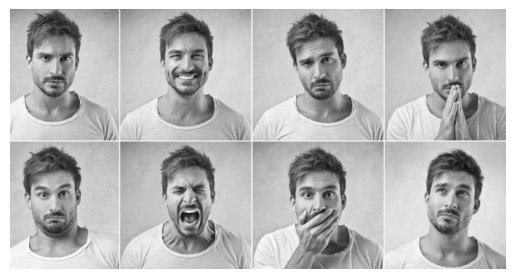

In [74]:
# Converting the image to grayscale.
original = image.copy()
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [76]:
face_cascade = cv2.CascadeClassifier('Material/haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, 1.1, 3)
faces
# these are just the positions of each image in the picture above.

array([[224,  35,  90,  90],
       [625,  49,  91,  91],
       [ 23,  41,  92,  92],
       [229, 242,  85,  85],
       [ 18, 243,  98,  98],
       [420,  43,  97,  97],
       [420, 242,  97,  97],
       [627, 241,  91,  91]])

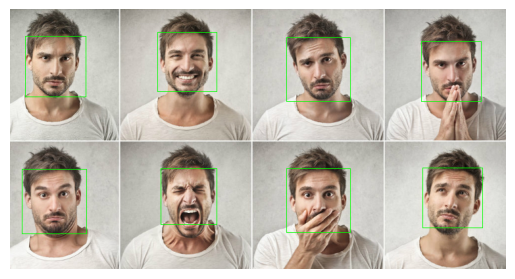

In [78]:
# itering between each face shown above and highlighting the faces encountered in each one of them
for (x,y,w,h) in faces:
    cv2.rectangle(original, (x,y), (x+w,y+h),(0,255,0),1)

plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

1/1 [==============================] - 0s 24ms/step


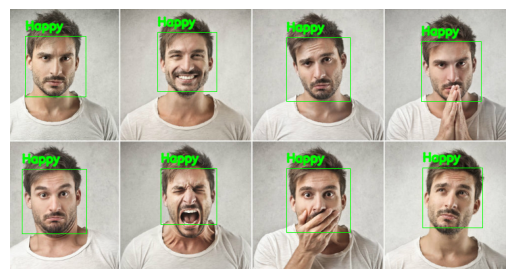

In [80]:
for (x,y,w,h) in faces:
    cv2.rectangle(original, (x,y), (x+w,y+h),(0,255,0),1)
    roi_gray = gray[y:y + h, x:x + w]
    roi_gray = roi_gray.astype('float') / 255.0
    # Setting the image up for tensorflow.
    cropped_img = np.expand_dims(np.expand_dims(cv2.resize(roi_gray,(48,48)),-1),0)
    prediction = loaded_model.predict(cropped_img)[0]
    cv2.putText(original, expressoes[int(np.argmax(prediction))], (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2, cv2.LINE_AA)

plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Trying Others CNN Architectures

In [1]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.models import model_from_json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import itertools
import cv2
import pandas as pd
import tensorflow as tf

In [3]:
num_features = 32
num_classes = 7
width, height = 48,48
batch_size=16
epochs=5

model = Sequential()

model.add(Conv2D(num_features, (3,3), padding='same', kernel_initializer='he_normal', input_shape=(width,height,1)))
model.add(Activation('elu')) # Different activation function from previous model 'relu'.
model.add(BatchNormalization())
model.add(Conv2D(num_features, (3,3), padding='same', kernel_initializer='he_normal', input_shape=(width,height,1)))
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2)) # Dropout value lower as well (previous was .5)

model.add(Conv2D(2*num_features, (3,3), padding='same', kernel_initializer='he_normal', input_shape=(width,height,1)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(2*num_features, (3,3), padding='same', kernel_initializer='he_normal', input_shape=(width,height,1)))
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(2*2*num_features, (3,3), padding='same', kernel_initializer='he_normal', input_shape=(width,height,1)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*num_features, (3,3), padding='same', kernel_initializer='he_normal', input_shape=(width,height,1)))
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(2*2*2*num_features, (3,3), padding='same', kernel_initializer='he_normal', input_shape=(width,height,1)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*2*num_features, (3,3), padding='same', kernel_initializer='he_normal', input_shape=(width,height,1)))
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(2*num_features, kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(2*num_features, kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(num_classes, kernel_initializer='he_normal'))
model.add(Activation('softmax'))

print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 32)        320       
                                                                 
 activation (Activation)     (None, 48, 48, 32)        0         
                                                                 
 batch_normalization (BatchN  (None, 48, 48, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 32)        9248      
                                                                 
 activation_1 (Activation)   (None, 48, 48, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 24, 24, 32)       0         
 )                                                    

In [4]:
# Compiling this new model:
model.compile(loss=categorical_crossentropy, optimizer=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-7),
              metrics=['accuracy'])
model_file = 'Material/modelo_02_expressoes.h5'
model_file_json = 'Material/modelo_02_expressoes.json'
lr_reducer = ReduceLROnPlateau(monitor='val_loss',factor=0.9,patience=3,verbose=1)
early_stopper = EarlyStopping(monitor='val_loss', min_delta=0,patience=8,verbose=1,mode='auto')
checkpointer = ModelCheckpoint(model_file, monitor='val_loss', verbose=1, save_best_only=True)

In [5]:
# Saving the model architecture into a JSON file
model_json = model.to_json()
with open(model_file_json, 'w') as json_file:
    json_file.write(model_json)

In [17]:
# Training the model
history = model.fit(np.array(X_train), np.array(y_train),
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(np.array(X_val),np.array(y_val)),
                    shuffle=True,
                    callbacks=[lr_reducer,early_stopper,checkpointer])

Epoch 1/5
1907/1907 [==============================] - ETA: 0s - loss: 1.8944 - accuracy: 0.2857
Epoch 1: val_loss improved from inf to 1.42067, saving model to Material\modelo_02_expressoes.h5
1907/1907 [==============================] - 270s 140ms/step - loss: 1.8944 - accuracy: 0.2857 - val_loss: 1.4207 - val_accuracy: 0.4493 - lr: 0.0010
Epoch 2/5
1907/1907 [==============================] - ETA: 0s - loss: 1.4414 - accuracy: 0.4461
Epoch 2: val_loss improved from 1.42067 to 1.28059, saving model to Material\modelo_02_expressoes.h5
1907/1907 [==============================] - 272s 143ms/step - loss: 1.4414 - accuracy: 0.4461 - val_loss: 1.2806 - val_accuracy: 0.5138 - lr: 0.0010
Epoch 3/5
1907/1907 [==============================] - ETA: 0s - loss: 1.3311 - accuracy: 0.4971
Epoch 3: val_loss improved from 1.28059 to 1.15244, saving model to Material\modelo_02_expressoes.h5
1907/1907 [==============================] - 271s 142ms/step - loss: 1.3311 - accuracy: 0.4971 - val_loss: 1.1

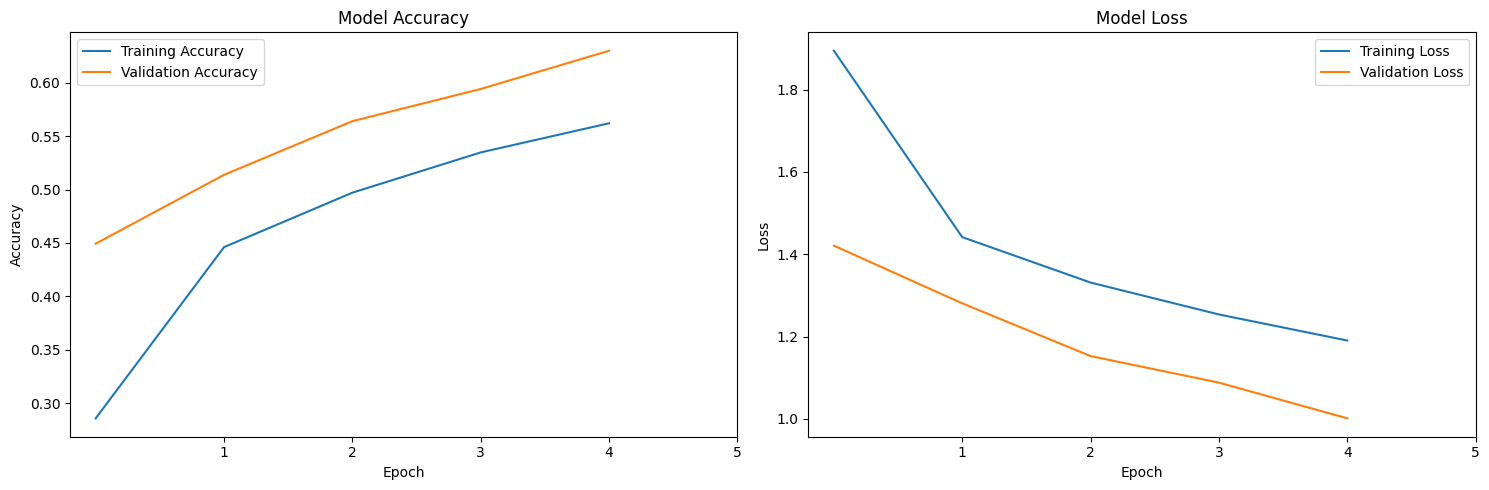

In [21]:
# Plotting the resuls
import numpy as np
import matplotlib.pyplot as plt

def plot_model_history(model_hist):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    # Subplot 0: Training and Validation Accuracy
    axs[0].plot(model_hist.history['accuracy'])
    axs[0].plot(model_hist.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    
    # Generate evenly spaced tick positions
    num_epochs = len(model_hist.history['accuracy'])
    xticks = np.arange(1, num_epochs + 1, max(1, num_epochs // 10))
    
    axs[0].set_xticks(xticks)
    axs[0].legend(['Training Accuracy', 'Validation Accuracy'], loc='best')

    # Subplot 1: Training and Validation Loss
    axs[1].plot(model_hist.history['loss'])
    axs[1].plot(model_hist.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_xticks(xticks)
    axs[1].legend(['Training Loss', 'Validation Loss'], loc='best')

    plt.tight_layout()
    plt.show()

plot_model_history(history)

[[   0    0    0  755    0    0    0]
 [   0    0    0   81    0    0    0]
 [   0    0    0  801    0    0    0]
 [   0    0    0 1307    0    0    0]
 [   0    0    0  900    0    0    0]
 [   0    0    0  601    0    0    0]
 [   0    0    0  939    0    0    0]]


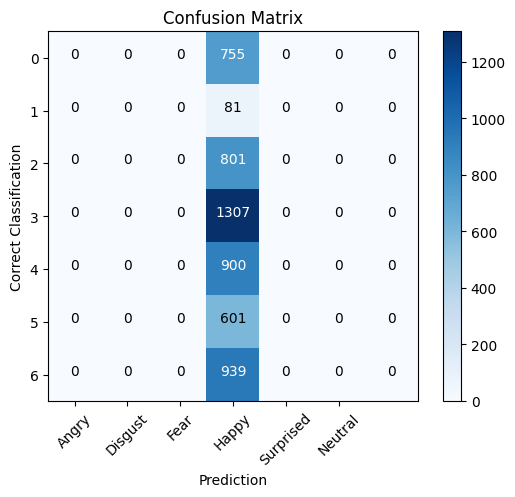

In [38]:
# Setting up the confusion matrix for better visualization of the results:

y_true = np.load('truey_mod01.npy')
y_pred = np.load('pred_mod01.npy')
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]
cm = confusion_matrix(y_true, y_pred)
expressions = ['Angry', 'Disgust', 'Fear', 'Happy','Surprised','Neutral']
title = 'Confusion Matrix'
print(cm)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(title)
plt.colorbar()
tick_marks = np.arange(len(expressions))
plt.xticks(tick_marks, expressions, rotation=45)
fmt = 'd'
thresh = cm.max() /2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i,j],fmt), horizontalalignment='center',color='white' if cm[i,j] > thresh else 'black')

plt.ylabel('Correct Classification')
plt.xlabel('Prediction')
plt.savefig('confusion_matrix_mod02.png')

# Emotion Identification in Videos

Since a video is made from lots of frames, it will work by applying each process studied above to each frame of the video, processing each one individually.

In [1]:
# Importing the necessary libraries
import cv2
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow

In [2]:
# Loading the model
from tensorflow.keras.models import load_model
model = load_model('Material/modelo_02_expressoes.h5')

In [3]:
# Loading the videos
video_file = 'Material/Videos/video_teste04.mp4'
cap = cv2.VideoCapture(video_file)

connected, video = cap.read()
print(connected, video.shape)

True (360, 640, 3)


In [4]:
# Resizing the video:
# In the case of these test videos, its not really necessary since the videos are not that big,
# but still, it will be done to achieve better computational performance.

resize = True
max_width = 600

if(resize and video.shape[1] > max_width):
    proportion = video.shape[1] / video.shape[0]
    video_width = max_width
    video_height = int(video_width / proportion)
else:
    video_width = video.shape[1]
    video_height = video.shape[0]

In [5]:
# Defining Video Settings
file_name = 'resultado_video_teste04.avi'

# Defining codec
# FourCC is a 4 bytes code thats used to specify the video codec.
# Most used codecs: XVID, MP4V, MJPG, DIVX, X264...
# For example, in order to save a video in a mp4 format, the mp4v codec is used:
fourcc = cv2.VideoWriter_fourcc(*'XVID')

# To make the video a bit slower, the amount of frames per second (fps) can be reduced as well:
fps = 24
video_output = cv2.VideoWriter(file_name, fourcc, fps, (video_width, video_height))

1/1 [==============================] - 0s 227ms/step
[0.08907695 0.01088615 0.08823664 0.38184816 0.19586016 0.02197113
 0.21212088]


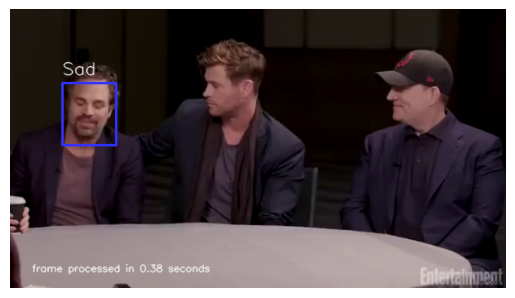

1/1 [==============================] - 0s 20ms/step
[0.08606713 0.0112916  0.09495969 0.4254258  0.17745923 0.02778308
 0.1770135 ]


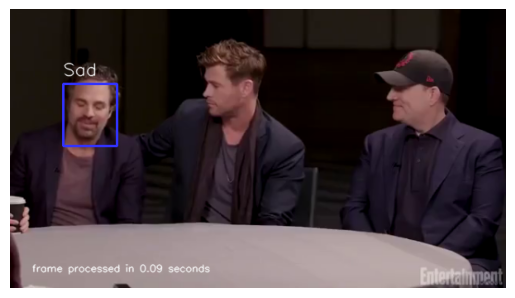

1/1 [==============================] - 0s 21ms/step
[0.13558175 0.02265007 0.14615972 0.17719857 0.30981508 0.02305984
 0.18553498]


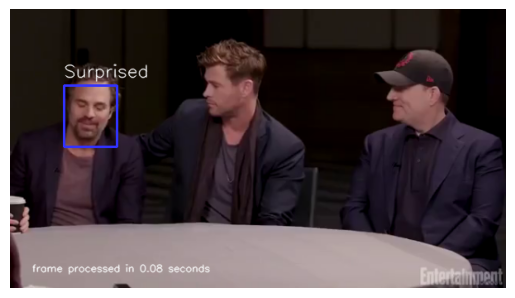

1/1 [==============================] - 0s 21ms/step
[0.14949536 0.02753531 0.15812282 0.17431282 0.30041155 0.02504298
 0.16507918]


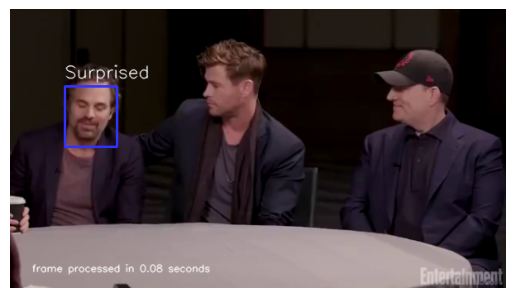

1/1 [==============================] - 0s 23ms/step
[0.12955141 0.01470161 0.121678   0.12448315 0.31969905 0.01803289
 0.27185392]


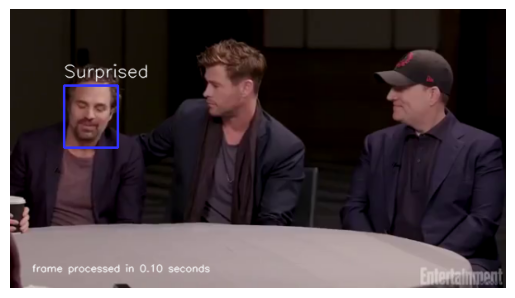

1/1 [==============================] - 0s 19ms/step
[0.14851445 0.02521897 0.11849755 0.22228767 0.31456366 0.01266026
 0.15825744]


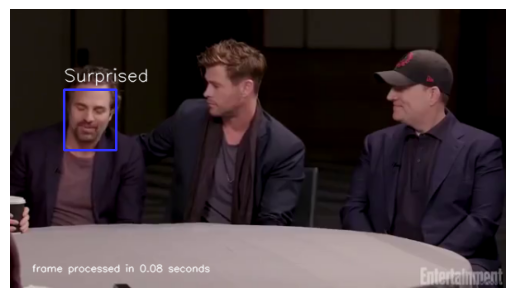

1/1 [==============================] - 0s 21ms/step
[0.13969277 0.02160092 0.11575738 0.1798716  0.35712135 0.01016081
 0.17579521]


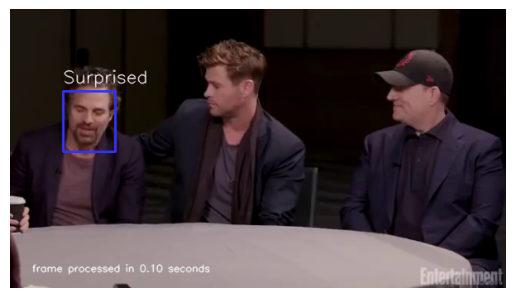

1/1 [==============================] - 0s 19ms/step
[0.13334627 0.02170356 0.11362138 0.2667523  0.30389115 0.01236334
 0.14832187]


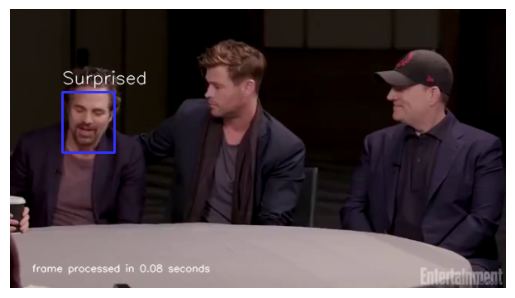

1/1 [==============================] - 0s 21ms/step
[0.08828877 0.0125108  0.07928999 0.5061505  0.18289532 0.013806
 0.11705865]


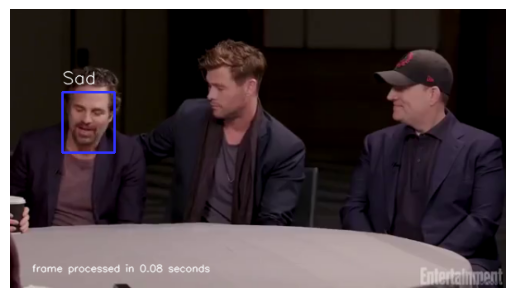

1/1 [==============================] - 0s 22ms/step
[0.13259976 0.02168404 0.11300544 0.253077   0.30710727 0.01313193
 0.15939452]


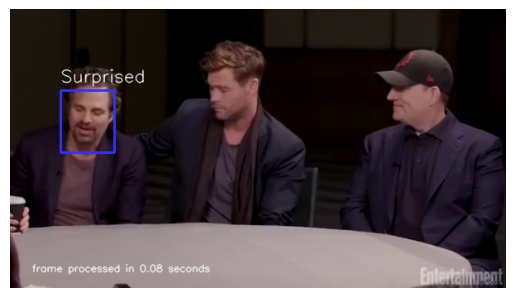

finished


In [6]:
# Processing the video and recording the result:
from tensorflow.keras.preprocessing.image import img_to_array

haarcascade_faces = 'Material/haarcascade_frontalface_default.xml'
small_font, medium_font = 0.4, 0.7
font = cv2.FONT_HERSHEY_SIMPLEX
expressions = ['Anger','Disgust','Fear','Sad','Surprised','Neutral']
i = 0

while(i < 10):
    connected, frame = cap.read()

    if not connected:
        break

    # Calcuting the amount of time taken to execute the operations
    t = time.time()
    if resize:
        frame = cv2.resize(frame, (video_width,video_height))

    face_cascade = cv2.CascadeClassifier(haarcascade_faces)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(30,30))

    if len(faces) > 0:
        for (x,y,w,h) in faces:
            frame = cv2.rectangle(frame,(x,y),(x+w,y+h+10),(255,50,50),2) # Drawing rectangles on the faces
            roi = gray[y:y + h, x:x + w]       # Extract only the Region Of Interest (ROI), which is the face region
            roi = cv2.resize(roi, (48,48))     # Before passing into a neural network, resize to the same size as the training images.
            roi = roi.astype('float') / 255.0  # Normalize the values, making them values from 0 to 1.
            roi = img_to_array(roi)            # Convert the image pixels to an array so the network can process it.
            roi = np.expand_dims(roi, axis=0)  # Change the shape of the array so it can be passed correctly into tensorflow
            
            # Makes the prediction, calculating the probabilites:
            result = model.predict(roi)[0]
            print(result)

            if result is not None:
                result = np.argmax(result) # Extract the higher probability emotion
                cv2.putText(frame, expressions[result], (x,y-10), font, medium_font, (255,255,255),1,cv2.LINE_AA) # Writes the emotion above
        
    cv2.putText(frame, ' frame processed in {:.2f} seconds'.format(time.time() - t), (20,video_height-20),font,small_font,
               (250,250,250), 0, lineType=cv2.LINE_AA)

    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    video_output.write(frame)
    i = i + 1

print('finished')
video_output.release()

### Observations about face detection on videos:

- When faces are so far away from the camera, to small or inclined; it may happen that the haarcascade not even be able to detect face in some frames.
- It may happen that the detection simply dont be successfully executed in some frames.
- Its possible to adjust the detectMultiScale() function parameters or even add one more haarcascade to detect faces in profile mode.
- It's also possible to use Dblib, which has better precision for face detection, at the cost at being significantly slower.